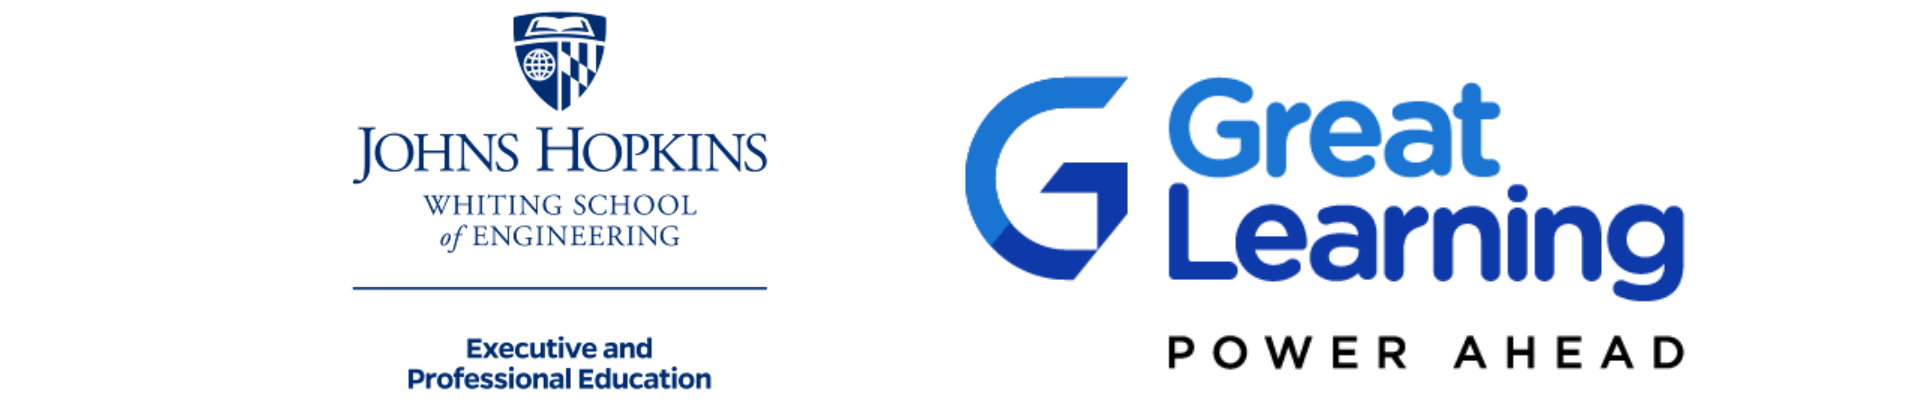

<div style='background: linear-gradient(135deg, #0d2b45 0%, #1f6f78 100%); padding: 32px; border-radius: 14px; color: white;'>
  
  <h1 style='margin: 0; font-size: 2.3em;'><b>🔍 DualLens Analytics — Trustworthy AI Investment Research</b></h1>
  <h2 style='margin: 12px 0 0 0; font-weight: 300;'>Grounded RAG · LLM-as-Judge Evaluation · Self-Improving Prompts (DSPy + GEPA) · Confidence-Routed Decisions</h2>
  <p style='margin: 18px 0 0 0; font-size: 1.05em;'>Build an AI research system that fuses live financial data with company strategy documents — and, unlike a naive chatbot, <b>measures</b> its own answer quality, <b>optimizes</b> its own prompt against a gold dataset, and <b>routes</b> its final recommendation by confidence so no untrusted answer ever reaches a client.</p>
</div>

## 🎯 **Learning Objectives**

By completing this notebook, you will be able to:

✅ **Fuse quantitative + qualitative data sources** — pull live market data with yfinance and combine it with insights retrieved from unstructured PDF reports.

✅ **Build a metadata-filtered RAG pipeline** — chunk, embed, and store documents in ChromaDB with company tags, so a question about MSFT never gets answered from GOOGL passages.

✅ **Diagnose retrieval separately from generation** — use a gold dataset to measure whether failures come from *fetching the wrong passages* or *answering badly from good passages*.

✅ **Design a 3-metric LLM-as-Judge harness** — score every answer on Groundedness, Context Relevance, and Answer Relevance with machine-readable rubrics, and cross-validate judges against an objective accuracy check.

✅ **Optimize prompts automatically with DSPy + GEPA** — recast the prompt as a typed `dspy.Signature`, drive GEPA with a deterministic gold-set metric, and prove the improvement on **held-out questions the optimizer never saw**.

✅ **Ship decisions with confidence routing** — aggregate evaluation signals into a confidence score and route the final investment ranking: client-ready / flagged / held for human review.

## 📊 **Marking Scheme (Total: 20 Marks)**

<div style='background-color: #fff3e0; padding: 18px; border-radius: 10px; border: 2px solid #ff9800;'>

### 📍 <font color="#c0392b">**Part 1 — Core Pipeline (8 marks)**</font>
<font color="#8e44ad">

- Financial lens — stock history + metrics DataFrame + visualizations — **2 marks**
- Narrative lens — PDF ingestion, chunking with company metadata, ChromaDB vector store — **2 marks**
- Grounded RAG function + 5-query typed test suite (incl. out-of-scope trap) — **3 marks**
- Retrieval diagnostics — gold-set hit-rate with vs. without the company filter — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 2 — Evaluation (5 marks)**</font>
<font color="#8e44ad">

- Three LLM-as-Judge rubrics (Groundedness, Context Relevance, Answer Relevance) + batch evaluation loop + pass/fail table — **3 marks**
- Objective gold-set accuracy check (`expected_substring`) + per-company breakdown + judge cross-validation — **2 marks**
</font>

### 📍 <font color="#c0392b">**Part 3 — Optimization & Decision Layer (5 marks)**</font>
<font color="#8e44ad">

- DSPy `Signature` + retrieval-aware `Module` + deterministic metric with feedback — **2 marks**
- GEPA compilation + evolved-prompt inspection + before/after comparison on the held-out test split — **2 marks**
- Fused ranking (financial + retrieved insights) + confidence score + routing verdict — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 4 — Summary & Future Scope (2 marks)**</font>
<font color="#8e44ad">

- Observations & learnings — **1 mark**
- Future scope (what would you build next?) — **1 mark**
</font>
</div>


---

### <font color="red"> **# Important Points To Note** </font>

1. For ALL LLM instances in this project (answerer, judges, DSPy task LM, GEPA reflection LM) use the **`"gpt-4o-mini"`** model only.
2. Look for cells marked **📝 YOUR TASK** — each gives you the function/class **skeleton** (names, signatures, docstrings, and step comments) with **`...` placeholders** where your code goes. Replace every `...` with your implementation; the skeleton tells you exactly what each piece must do.
3. **Do not rename** the skeleton's functions, classes, or variables — later **provided** cells depend on these exact names and will fail otherwise.
4. **💡 Hints** appear inside the trickier tasks. Cells without hints are expected to be within reach.
5. **Do not modify** the provided cells, the evaluation question set, the five typed test questions, or the gold-split parameters (`test_size=0.4`, `random_state=42`) — these keep your run comparable with the model solution released after submission.
6. For project submission, please provide the project in **HTML format.** Refer to the **"Guidelines: Converting IPYNB to HTML Files.pdf"** for instructions. Ensure all **outputs are clearly visible**, and enclose prompts in triple quotes **`"""`** so they remain fully visible after conversion.

---

## 📑 **Table of Contents**

1. [Introduction & Business Problem](#section1)
2. [System Architecture Overview](#section2)
3. [Environment Setup](#section3)
4. [Step 1 — Financial Lens: Market Data & Visualization](#section4)
5. [Step 2 — Narrative Lens: Document Ingestion & Vectorization](#section5)
6. [Step 3 — Grounded Q&A: The RAG Pipeline](#section6)
7. [Step 4 — Quality Control: LLM-as-Judge Evaluation](#section7)
8. [Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA](#section8)
9. [Step 6 — Decision Layer: Fused Ranking + Confidence Routing](#section9)
10. [Step 7 — Summary & Future Scope](#section10)

## 📖 **Glossary**

Skim this once before reading the rest — the notebook uses these terms throughout.

<div style='background-color: #f0f4ff; padding: 16px; border-radius: 8px; border-left: 4px solid #1f6f78;'>

### 💼 Domain terms

| Term | Meaning |
|---|---|
| **Market Cap** | Total market value of a company's outstanding shares. |
| **P/E Ratio** | Price-to-Earnings — how much investors pay per dollar of earnings. High P/E = priced for growth. |
| **Dividend Yield** | Annual dividend income as a percentage of the stock price. |
| **Beta** | A stock's volatility relative to the overall market (1.0 = moves with the market). |
| **Grounding** | Forcing every claim in an AI answer to trace back to a source document the firm has verified. |
| **Hallucination** | A confident AI claim that does **not** exist in any source document — the failure that almost shipped to a DualLens client. |
| **Gold dataset** | `golden_retrieval.csv` — 20 questions with verified correct answers (`expected_substring`) drawn from the source PDFs. Our objective measuring stick. |
| **Confidence routing** | Sending outputs down different paths based on measured quality: client-ready / flagged / held for human review. |

</div>

<div style='background-color: #f4f0ff; padding: 16px; border-radius: 8px; border-left: 4px solid #6a3ec9; margin-top: 10px;'>

### 🧠 Technical terms

| Term | Meaning |
|---|---|
| **RAG** | Retrieval-Augmented Generation — fetch the most relevant document passages, then have the LLM answer **only** from them. |
| **Chunk** | A small, overlapping slice of a document (~512 tokens here) — the unit that gets embedded and retrieved. |
| **Embedding** | A numerical "fingerprint of meaning" for a chunk of text. Similar meanings → nearby vectors. |
| **Vector store** | A database (ChromaDB here) that finds chunks whose embeddings are most similar to a question's embedding. |
| **Metadata filter** | Restricting retrieval to chunks tagged with a specific company — our fix for cross-company contamination. |
| **LLM-as-Judge** | Using an LLM with a scoring rubric to grade another LLM's output (1–5 here, with a machine-readable `Score: N` line). |
| **Groundedness** | Judge metric: are the answer's claims actually supported by the retrieved context? |
| **Context Relevance** | Judge metric: did the **retriever** fetch passages that can answer the question? (Evaluates retrieval, not generation.) |
| **Answer Relevance** | Judge metric: does the answer actually address what was asked? |
| **DSPy Signature** | A typed prompt contract — the docstring *is* the prompt, and inputs/outputs are declared fields. |
| **GEPA** | A reflection-based prompt optimizer: score candidates → read failure feedback → rewrite the prompt → keep the winners → repeat. |
| **Reflection LM** | The model inside GEPA that reads the metric's feedback and proposes the next prompt rewrite. |
| **Train/test split** | Letting the optimizer learn from one slice of the gold set (12 questions) and proving generalization on a hidden slice (8 questions). |

</div>

<a name='section1'></a>
## 1️⃣ **Introduction & Business Problem**

### 💼 **The Challenge**

**DualLens Analytics** is a boutique investment research firm. Its analysts answer one deceptively simple question for clients: *"Which technology companies are worth investing in right now?"*

Answering it well requires two lenses at once:

- **The numbers lens** — stock trends, market capitalization, revenue, valuation ratios. Structured, abundant, easy to chart.
- **The narrative lens** — what a company is actually *building* for the future, especially its AI initiatives. This lives in long strategy reports: unstructured, dense, slow to read.

Until recently the narrative lens was manual: 10–12 analyst-hours per company, per refresh, across a five-company universe (**GOOGL, MSFT, IBM, NVDA, AMZN**).

Six months ago the firm piloted an AI assistant — paste the documents into an LLM, ask questions, get answers. It was fast, and it became a liability. In a client-facing report the assistant confidently described an NVDA project timeline **that didn't exist in any source document**. A senior analyst caught it two hours before the report shipped. An internal audit found the same pattern repeatedly:

- Answers that mixed up **which company** a project belonged to
- **Fabricated specifics** (dates, dollar figures) not present in any document
- **No way to tell** a reliable answer from an unreliable one — every answer *sounded* equally confident

The firm's conclusion: the problem was never getting an AI to produce answers. The problem is producing answers you can **trust, measure, and improve**.

### 💡 **The Solution**

**DualLens 2.0** — a RAG system with a built-in quality-control layer and a self-improving prompt:

1. **Grounds every answer in source documents** — retrieval + a strict "answer only from context, else say *I don't know*" contract.
2. **Measures answer quality automatically** — an LLM judge scores every answer on three dimensions, cross-checked against an objective gold dataset.
3. **Improves its own prompt** — GEPA reads failure feedback and rewrites the prompt, with the improvement *proven* on questions the optimizer never saw.
4. **Routes outputs by confidence** — the final investment ranking carries a confidence score; low-confidence outputs are held for human review, never silently trusted.

### 💸 **Cost of Inaction**

One shipped hallucination in a client report risks regulatory scrutiny and the firm's reputation. Reverting to manual reading means the research desk simply cannot scale beyond five companies. The system below is what turns analysts from *document readers* into *reviewers of flagged outputs*.

<a name='section2'></a>
## 2️⃣ **System Architecture Overview**

### 🏗️ **The Evaluation-Driven Pipeline**

Unlike the failed pilot — which generated answers and stopped — every generation stage here is paired with a measurement stage, and the measurements feed back into improving the system.

```
 ┌─────────────────────┐        ┌──────────────────────────┐
 │  STEP 1             │        │  STEP 2                  │
 │  Financial Lens     │        │  Narrative Lens          │
 │  yfinance → charts  │        │  PDFs → chunks → Chroma  │
 │  + metrics table    │        │  (+ company metadata)    │
 └─────────┬───────────┘        └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 3                  │
           │                    │  Grounded RAG Q&A        │
           │                    │  filtered retrieval +    │
           │                    │  strict-context prompt   │
           │                    └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 4                  │
           │                    │  Judge Harness (3 LLM    │
           │                    │  metrics) + Gold-set     │
           │                    │  objective accuracy      │
           │                    └────────────┬─────────────┘
           │                                 │ failure feedback
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 5                  │
           │                    │  DSPy + GEPA prompt      │
           │                    │  optimization (train 12, │
           │                    │  prove on held-out 8)    │
           │                    └────────────┬─────────────┘
           │                                 │ optimized RAG
           └────────────────┬────────────────┘
                            │
               ┌────────────▼─────────────┐
               │  STEP 6                  │
               │  Fused Ranking +         │
               │  Confidence Score        │
               │  ✅ client-ready          │
               │  ⚠️ flagged               │
               │  🛑 held for human review │
               └──────────────────────────┘
```

### 🤖 **Cast of Characters (all `gpt-4o-mini`)**

| Role | Job | Settings |
|---|---|---|
| **Answerer LLM** | Generates grounded answers from retrieved context | `temperature=0` (deterministic) |
| **Judge LLM** | Scores answers on the three 1–5 rubrics | `temperature=0`, separate object from the answerer |
| **Task LM (DSPy)** | Runs candidate prompts during GEPA compilation | `temperature=0.1` |
| **Reflection LM (GEPA)** | Reads failure feedback, proposes prompt rewrites | `temperature=1.0` — creative variation helps reflection |

> 💰 **Single-model cost note.** A production setup would typically use a *stronger* model as judge/reflector. We run everything on `gpt-4o-mini` to keep costs minimal — and the design choice that makes this viable is the **deterministic gold-set metric** in Step 5: the optimization loop is scored by free Python (substring checks), not by noisy small-model judge calls. This trade-off is itself a real-world lesson.

### 🔁 **Logical Flow**

1. Build both lenses (Steps 1–2) → 2. Answer questions with grounded RAG (Step 3) → 3. Measure quality with judges + the gold dataset (Step 4) → 4. Let GEPA optimize the prompt against the gold-set metric and prove it generalizes (Step 5) → 5. Fuse both lenses into a ranked recommendation, score its confidence, and route it (Step 6).

<a name='section3'></a>
## 3️⃣ **Environment Setup**

### 3.1 · Install dependencies

In [28]:
# Installing the Libraries
!pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "dspy==3.2.1" \
    "scikit-learn>=1.4" \
    "yfinance>=0.2.40"
print("### Library Installation - Done")

### Library Installation - Done


**Note:** Messages above may appear as errors, but they can be safely ignored. They are caused by minor dependency mismatches in optional packages and do not affect the functionality of this notebook.

### After installation, please **restart the runtime** and **do not re-run the above cell**. Continue execution from the next cell below.

### 3.2 · Load your OpenAI API key

- The `config.json` file should contain the **API_KEY** and **API BASE URL** provided for your account.
- Refer to the **OpenAI Access Token documentation** for how to generate and manage your API keys.
- The `config.json` should look like this:

```
{
    "API_KEY": "your_openai_api_key_here",
    "OPENAI_API_BASE": "https://your_openai_api_base/v1"
}
```

In [29]:
# Load the `config.json` file and extract API key + base URL
import json
import os

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY")           # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")  # Loading the API Base URL

print("API credentials loaded into the environment.")

API credentials loaded into the environment.


In [30]:
# Quick connectivity check — confirms the key + base URL actually reach a working endpoint
from openai import OpenAI

_client = OpenAI()
_ping = _client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: OK"}],
    max_tokens=5,
)
print("Connectivity check:", _ping.choices[0].message.content)

Connectivity check: OK


### 3.3 · Configuration & shared imports

One place for every knob the notebook uses. If you change a model or a retrieval depth, change it here.

In [31]:
# Core imports used across the notebook.
import warnings
warnings.filterwarnings('ignore')

import re
import time
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

pd.set_option("display.max_colwidth", 120)

In [32]:
# ---- Models ----------------------------------------------------------
# Single-model setup: gpt-4o-mini everywhere (see the cost note in Section 2).
MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# ---- Companies under coverage ----------------------------------------
COMPANIES = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# ---- Retrieval & chunking knobs --------------------------------------
CHUNK_SIZE    = 512   # tokens per chunk (token-based splitting matches what models actually count)
CHUNK_OVERLAP = 64    # tokens shared between neighbouring chunks, so facts at boundaries aren't cut in half
TOP_K         = 4     # chunks retrieved per question

# ---- Evaluation & routing policy --------------------------------------
PASS_THRESHOLD       = 4      # a judge metric "passes" at >= 4 out of 5
CONF_CLIENT_READY    = 80     # confidence >= 80  -> ✅ client-ready
CONF_FLAGGED         = 60     # 60 <= conf < 80   -> ⚠️ flagged for awareness
                              # conf < 60         -> 🛑 held for human review

# ---- LLM objects -------------------------------------------------------
# Answerer — generates the RAG response. temperature=0 keeps answers stable
# and grounded; max_tokens caps response length.
llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=1024)

# Judge — a SEPARATE object so the evaluation role is explicit. In production
# this would be a stronger model; here it shares gpt-4o-mini for cost, which
# is exactly why Step 4 cross-validates the judges against the gold dataset.
judge_llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=600)

print(f"Configured: answerer={MODEL_NAME}, judge={MODEL_NAME}, embeddings={EMBEDDING_MODEL}")

Configured: answerer=gpt-4o-mini, judge=gpt-4o-mini, embeddings=text-embedding-3-small


<a name='section4'></a>
## 4️⃣ **Step 1 — Financial Lens: Market Data & Visualization**

The quantitative half of DualLens. We pull three years of price history plus five headline financial metrics for the coverage universe, and visualize them. These numbers feed the fused ranking in Step 6.

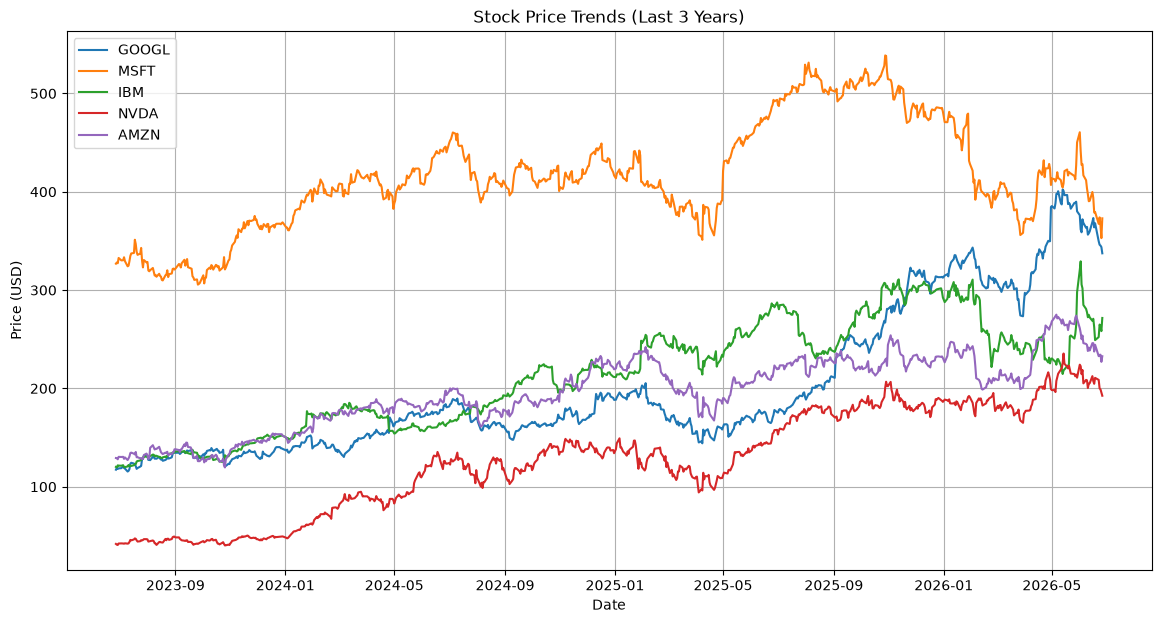

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Three-year price trend chart
# ═══════════════════════════════════════════════════════════════════════════
# One shared figure: the 3-year closing-price trend of all five companies.
# Replace each `...` below.
# ───────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7))

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period='3y')          # YOUR CODE: fetch this ticker's daily history for the last 3 years
    plt.plot(data.index, data['Close'], label=symbol)                 # YOUR CODE: plot the 'Close' series for this company, labelled with its symbol

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### 💹 Financial Metrics

1. **Market Cap** — total market value of a company's outstanding shares.
2. **P/E Ratio** — how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield** — annual dividend income as a percentage of the stock price.
4. **Beta** — a stock's volatility relative to the overall market.
5. **Total Revenue** — total income generated from business operations.

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Financial metrics DataFrame
# ═══════════════════════════════════════════════════════════════════════════
# Fetch the five headline metrics per company into `fin_df`.
# "Market Cap" is done for you as the worked example — complete the other four.
# 💡 Hint: explore ticker.info's keys; use .get(key, 0) since some companies
#          don't report every field.
# ───────────────────────────────────────────────────────────────────────────
metrics_list = {}

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {
        "Market Cap":     info.get("marketCap", 0),     # worked example
        "P/E Ratio":      info.get("trailingPE", 0),                          # YOUR CODE
        "Dividend Yield": info.get("dividendYield", 0),                          # YOUR CODE
        "Beta":           info.get("beta", 0),                          # YOUR CODE
        "Total Revenue":  info.get("totalRevenue", 0),                          # YOUR CODE
    }

# Convert to a DataFrame (companies as the index) and make it readable:
fin_df = pd.DataFrame(metrics_list).T
fin_df["Market Cap"]    = fin_df["Market Cap"] / 1e9        # YOUR CODE: rescale to USD billions
fin_df["Total Revenue"] = fin_df["Total Revenue"] / 1e9        # YOUR CODE: rescale to USD billions
fin_df = fin_df.round(2)

fin_df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4117.03,25.72,0.26,1.24,422.50
MSFT,2770.58,22.23,0.98,1.10,318.27
IBM,255.30,24.04,2.49,0.66,68.91
NVDA,4663.27,29.48,0.52,2.20,253.49
AMZN,2503.07,31.66,0.00,1.44,742.78


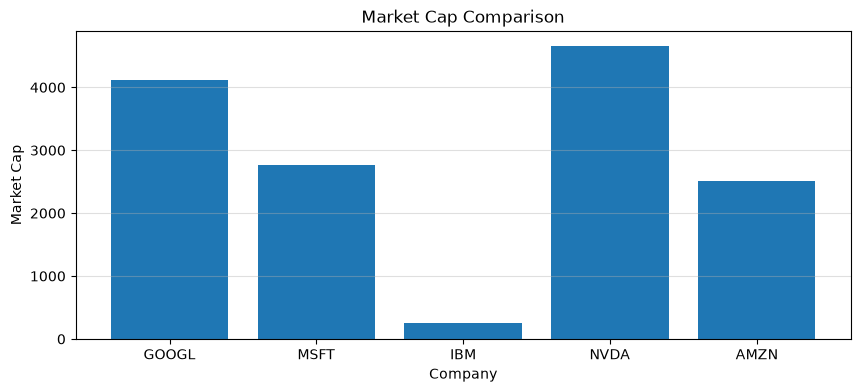

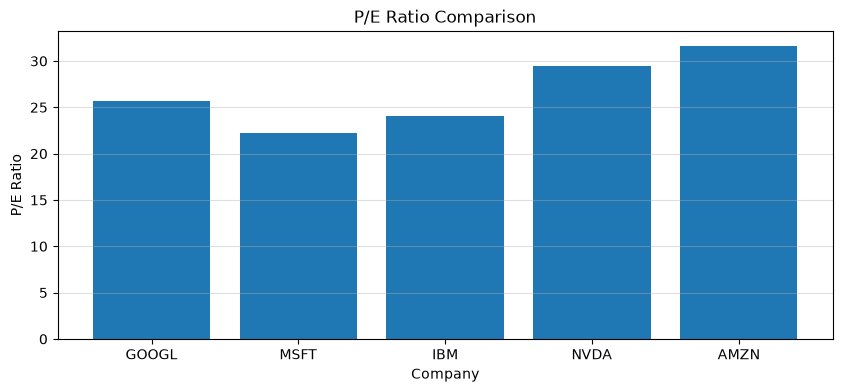

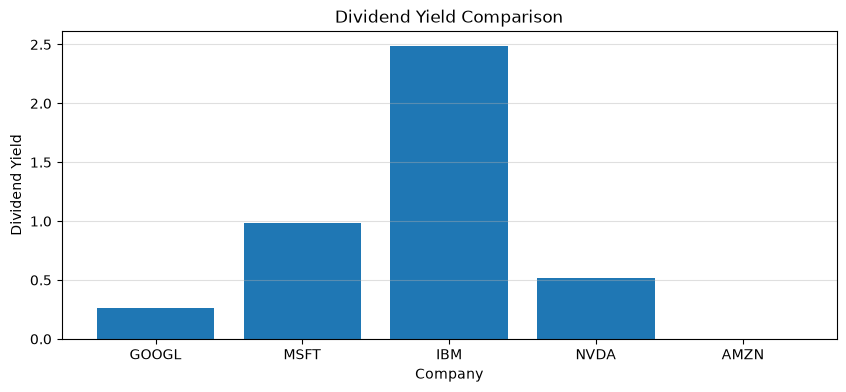

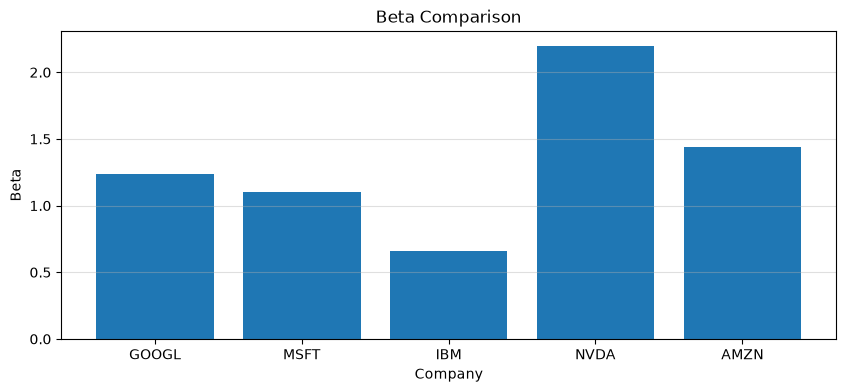

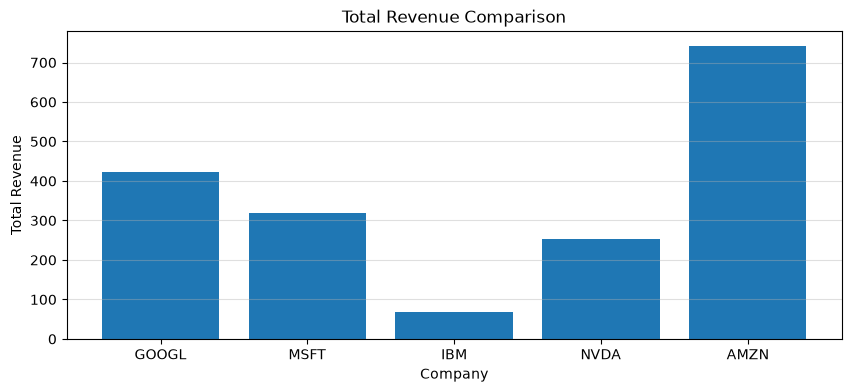

In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-metric comparison charts
# ═══════════════════════════════════════════════════════════════════════════
# One bar chart per metric, comparing all five companies.
# ───────────────────────────────────────────────────────────────────────────
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(fin_df.index, fin_df[metric])                              # YOUR CODE: bar chart of fin_df[metric] across companies
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

### 🔎 Your Observations — The Financial Lens

*Write 2–4 bullets. Consider:*
- *Which company do the metrics suggest is "priced for growth", and which looks like a defensive/dividend profile? What evidence?*
- *What investment-relevant question can these numbers NOT answer — and where would that answer live instead?*
- *Note: yfinance returns live data, so describe the pattern you actually see in your run.*

- NVDA has the highest Market Cap (~$4.6T) despite having lower Total Revenue than GOOGL and AMZN.
- AMZN has the highest P/E ratio, suggesting it is priced for growth, while IBM shows the highest Dividend Yield (~2.5%) and lowest Beta (~0.6), indicating a defensive/dividend profile.
- These metrics can tell us the profitability and market sentiment towards these companies, but it cannot tell their strategies. That information can only be found in their published documents.

<a name='section5'></a>
## 5️⃣ **Step 2 — Narrative Lens: Document Ingestion & Vectorization**

The qualitative half. Five PDF reports (one per company) describing each organization's AI initiatives — summaries, objectives, timelines, investments, risks.

**The one design decision that matters most in this section:** every chunk gets a `company` **metadata tag** derived from its source filename. In the failed pilot, a question about MSFT could be answered from GOOGL passages because all documents lived in one undifferentiated pool. The tag is what lets us *filter* retrieval per company in Step 3 — and *measure* how much that filter helps.

In [36]:
# 📂 Unzip the AI-initiative documents into the working directory.
ZIP_PATH    = "./content/Project_Datafiles.zip"
EXTRACT_DIR = "./content/"
PDF_DIR     = "./content/Companies-AI-Initiatives"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

pdf_files = sorted(f for f in os.listdir(PDF_DIR) if f.endswith(".pdf"))
print("Documents found:", pdf_files)

Documents found: ['AMZN.pdf', 'GOOGL.pdf', 'IBM.pdf', 'MSFT.pdf', 'NVDA.pdf']


In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Load PDFs and tag every page with its company
# ═══════════════════════════════════════════════════════════════════════════
# This tag is what makes company-filtered retrieval possible in Step 3 — the
# fix for the pilot's company-mix-up failures. (It's also why we load each
# file individually instead of using PyPDFDirectoryLoader.)
# ───────────────────────────────────────────────────────────────────────────
documents = []

for fname in pdf_files:
    ticker = fname.replace(".pdf", "")     # "MSFT.pdf" -> "MSFT"
    loader = PyPDFLoader(f"{PDF_DIR}/{fname}")                           # YOUR CODE: a PyPDFLoader for this file's full path
    pages  = loader.load()                           # YOUR CODE: load the file (one Document per page)
    for page in pages:
        page.metadata["company"] = ticker                                # YOUR CODE: set this page's "company" metadata to the ticker
    documents.extend(pages)

print(f"Loaded {len(documents)} pages across {len(pdf_files)} companies.")

Loaded 44 pages across 5 companies.


In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Token-based chunking
# ═══════════════════════════════════════════════════════════════════════════
# Split the tagged pages into overlapping, token-sized chunks. Token-based
# splitting aligns chunk sizes with what the models actually count, and
# splitting Documents (not raw text) carries your company tag onto every chunk.
# 💡 Hint: the splitter has a class method for tiktoken-based sizing
#          ('cl100k_base'), and a method that splits Document objects while
#          preserving their metadata.
# ───────────────────────────────────────────────────────────────────────────
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=CHUNK_SIZE,        # YOUR CODE: use the constant from Section 3.3
    chunk_overlap=CHUNK_OVERLAP,     # YOUR CODE: use the constant from Section 3.3
)

chunks = text_splitter.split_documents(documents)               # YOUR CODE: split `documents` so metadata is preserved
print(f"Total chunks: {len(chunks)}")

Total chunks: 108


In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Sanity-check the chunks
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: collections.Counter over each chunk's company metadata is a one-liner.
# ───────────────────────────────────────────────────────────────────────────
chunk_counts = Counter(chunk.metadata["company"] for chunk in chunks)         # YOUR CODE: chunks per company
print("Chunks per company:", dict(chunk_counts))
print()
print("--- Sample chunk (first 400 chars) ---")
print(chunks[0].page_content[:400])                        # YOUR CODE: print the first ~400 chars of one chunk
print()
print("Metadata:", chunks[0].metadata)                        # YOUR CODE: print that chunk's metadata (confirm the company tag)

Chunks per company: {'AMZN': 25, 'GOOGL': 17, 'IBM': 22, 'MSFT': 19, 'NVDA': 25}

--- Sample chunk (first 400 chars) ---
Amazon  is  a  global  technology  and  e-commerce  giant  that  uses  AI  to  enhance  almost  every  part  
of
 
its
 
business.
 
In
 
retail,
 
AI
 
powers
 
product
 
recommendations,
 
dynamic
 
pricing,
 
fraud
 
detection,
 
and
 
supply
 
chain
 
optimization,
 
making
 
shopping
 
faster
 
and
 
more
 
personalized.
 
Amazon
 
Web
 
Services
 
(AWS)
 
offers
 
AI
 
and
 
machine
 
learni

Metadata: {'producer': 'Skia/PDF m142 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'AI Initiatives', 'source': './content/Companies-AI-Initiatives/AMZN.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1', 'company': 'AMZN'}


In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Embed and store in ChromaDB
# ═══════════════════════════════════════════════════════════════════════════
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)   # YOUR CODE: the EMBEDDING_MODEL constant

vectorstore = Chroma.from_documents(
    chunks,                                        # YOUR CODE: your chunks
    embedding_model,                                        # YOUR CODE: your embedding model
    collection_name="ai_initiatives",
)

print(f"Vector store ready with {vectorstore._collection.count()} embedded chunks.")

Vector store ready with 216 embedded chunks.


### 🔎 Your Observations — Ingestion & Vectorization

*Write 2–3 bullets. Consider:*
- *Are chunk counts balanced across companies, and why would an imbalance distort retrieval?*
- *The five companies describe their AI work in very similar language ("cloud AI platform", "foundation models"). What does the metadata tag guarantee that embedding similarity alone might not — and in which kinds of queries does that guarantee matter most?*
- *What trade-off do CHUNK_SIZE / CHUNK_OVERLAP control?*

- The chunk counts are uneven (GOOGL: 17, IBM: 22, MSFT: 19, AMZN: 25, NVDA: 25). In an unfiltered search, data from the GOOGL tagged documents would be underrepresented vs. NVDA or AMZN.
- Since each company uses very similar language, their chunks will look similar in a vector space. Given a similarity search alone, a chunk from an IBM document could be returned when requesting information for MSFT. With the {company} metadata tag, the results are filtered for the targeted company before the similarity scoring, which will matter most for specific factual questions for that target company, like specific dates or financial information.
- Chunk size determines the amount of data in each chunk, while chunk overlap will control how much data will overlap between the end of one chunch and the start of the next. A large chunk size can provide the LLM with greater context, but will cost more tokens. A larger chunk overlap will ensure that context is not lost between the chunks, but can again result in costly token usage.

<a name='section6'></a>
## 6️⃣ **Step 3 — Grounded Q&A: The RAG Pipeline**

### 6.1 · Prompt design

The grounding contract lives in the system prompt: the model may use **only** the supplied context (marked `###Context`), must answer the question (marked `###Question`), and must reply exactly **"I don't know."** when the context lacks the answer. This is the guardrail the failed pilot never had — it converts "confident fabrication" into an honest, detectable miss.

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the v1.0 grounding system prompt
# ═══════════════════════════════════════════════════════════════════════════
# Write the rules INSIDE the triple quotes. The prompt must instruct the model to:
#   • Use ONLY the information in the supplied context
#   • Respond EXACTLY with: "I don't know." when the context lacks the answer
#   • Never reference the context's structure (no "based on the context...")
#
# ⚠️ Keep it MINIMAL — resist adding extra instructions. This is deliberately
#    your v1.0: Step 4 will measure its weaknesses and Step 5 will let GEPA
#    evolve it. Hand-tuning it now destroys the experiment.
# ───────────────────────────────────────────────────────────────────────────
qna_system_message = """
Answer the question using ONLY the information in the context provided.
If the context does not contain enough information to answer the question, respond with exactly: I don't know.
Do not mention the context, do not say "based on the context", and do not add information from outside the context.
"""


In [42]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

### 6.2 · Company-filtered retrieval

`retrieve()` is the single retrieval doorway for the whole notebook. Pass a `company` ticker and Chroma restricts the similarity search to that company's chunks; pass `None` (for cross-company questions) and it searches the full pool.

In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the retrieval helper
# ═══════════════════════════════════════════════════════════════════════════
# Every retrieval in this notebook goes through retrieve().
# 💡 Hint: vectorstore.similarity_search() accepts a `filter` argument that
#          takes a metadata dictionary.
# ───────────────────────────────────────────────────────────────────────────
def retrieve(question: str, company: str | None = None, k: int = TOP_K):
    """Return the top-k most similar chunks, optionally restricted to one company.

    Args:
        question: Natural-language question to embed and search with.
        company:  Ticker like "MSFT" to filter on, or None for the full pool.
        k:        Number of chunks to return.
    """
    search_filter = {"company": company} if company else None     # YOUR CODE: a metadata filter dict when company is given, else None
    return vectorstore.similarity_search(question, k=k, filter=search_filter)              # YOUR CODE: similarity search with k and the filter


def format_context(docs) -> str:
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)    # provided

In [44]:
# 🧪 Demonstrate retrieval end-to-end before wiring the LLM in:
# ask an MSFT question, confirm every returned chunk is tagged MSFT.
demo_question = "What is Microsoft's flagship AI assistant product?"
demo_chunks = retrieve(demo_question, company="MSFT")

print(f"Retrieved {len(demo_chunks)} chunks. Company tags:",
      [c.metadata["company"] for c in demo_chunks])
print()
print("--- First chunk (first 400 chars) ---")
print(demo_chunks[0].page_content[:400])

Retrieved 4 chunks. Company tags: ['MSFT', 'MSFT', 'MSFT', 'MSFT']

--- First chunk (first 400 chars) ---
Microsoft,  founded  in  1975,  is  a  global  technology  leader  specializing  in  software,  cloud  
computing,
 
AI,
 
and
 
enterprise
 
solutions.
 
The
 
company
 
has
 
aggressively
 
expanded
 
its
 
AI
 
capabilities
 
through
 
initiatives
 
such
 
as
 
Azure
 
AI,
 
OpenAI
 
partnership
 
integrations,
 
and
 
proprietary
 
models
 
like
 
Copilot,
 
which
 
enhance
 
productivity
 
in


### 6.3 · The RAG function

In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The grounded RAG function: retrieve -> assemble -> answer
# ═══════════════════════════════════════════════════════════════════════════
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])                                              # provided

def rag_answer(question: str, company: str | None = None) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        question: The user's natural-language question.
        company:  Optional ticker to restrict retrieval to one company's documents.
    Returns:
        The model's answer, grounded in the retrieved context.
    """
    relevant_chunks = retrieve(question, company=company)    # YOUR CODE: retrieve, passing the company filter through
    context = format_context(relevant_chunks)            # YOUR CODE: format the chunks into one context string

    messages = qna_prompt.format_messages(context=context, question=question)           # YOUR CODE: format qna_prompt with the context and question
    response = llm.invoke(messages)           # YOUR CODE: invoke `llm` with the messages
    return response.content

### 6.4 · Typed test suite

Five queries, each probing a different capability. (These are smoke tests for *behaviour*; the rigorous *measurement* happens in Step 4.)

### Example 1: Factual lookup — a single specific fact from one company's document.

In [46]:
# Example 1: factual lookup (single fact, single company)
print(rag_answer("What is Microsoft's flagship AI assistant product brand?", company="MSFT"))

Microsoft 365 Copilot


### Example 2: Listing question — can retrieval surface multiple related facts in one answer?

In [47]:
# Example 2: listing / multi-fact recall
print(rag_answer("What are the main AI initiatives NVIDIA is working on?", company="NVDA"))

The main AI initiatives NVIDIA is working on include deep learning, generative AI, digital twins, and industrial automation.


### Example 3: Cross-company comparison — retrieval over the **full pool** (company=None), since the question spans two companies.

In [48]:
# Example 3: cross-company comparison — no filter, the question itself names both companies
print(rag_answer("How does Google's AI focus differ from Microsoft's AI focus?", company=None))

I don't know.


### Example 4: Multi-hop synthesis — connecting facts across chunks of the same document.

In [49]:
# Example 4: multi-hop synthesis — links Amazon's customer-facing platform to its in-house foundation model
print(rag_answer("What is Amazon's foundation-model platform, and what foundation model has Amazon developed in-house?", company="AMZN"))

Amazon's foundation-model platform is called Amazon Bedrock. The context does not specify a foundation model that Amazon has developed in-house.


### Example 5: Out-of-scope trap — validates the **"I don't know"** guardrail. The documents describe AI initiatives, not quarterly financials, so the only correct answer is an honest miss.

In [50]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


### 6.5 · Retrieval diagnostics with the gold dataset

`golden_retrieval.csv` contains **20 questions** (4 per company), each with:

| Column | Meaning |
|---|---|
| `question` | A question answerable from exactly one company's document |
| `ticker_hint` | Which company's document holds the answer |
| `expected_substring` | A short, verified token (e.g., *Copilot*, *Granite*, *Bedrock*) that a correct answer **must** contain |

Here we use it to answer a question the judges in Step 4 *cannot* answer on their own: **when the system fails, is it the retriever's fault or the generator's fault?** We check whether the expected token appears in the *retrieved chunks* (before any LLM is involved) — with the company filter on vs. off.

In [51]:
# 📂 Load the gold dataset
gold = pd.read_csv("./content/golden_retrieval.csv")
print(f"{len(gold)} gold questions, balanced across companies:")
print(gold["ticker_hint"].value_counts().to_dict())
gold.head()

20 gold questions, balanced across companies:
{'MSFT': 4, 'GOOGL': 4, 'IBM': 4, 'NVDA': 4, 'AMZN': 4}


,question,ticker_hint,expected_substring
0,What is Microsoft's flagship AI assistant product brand?,MSFT,Copilot
1,Which Microsoft cloud platform hosts AI services?,MSFT,Azure
2,What is Microsoft's AI development platform for foundation models?,MSFT,Foundry
3,Which Microsoft tool delivers AI-assisted code completion?,MSFT,IntelliCode
4,What is Google's primary foundation-model family?,GOOGL,Gemini


In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Retrieval-only diagnostic: filter ON vs filter OFF
# ═══════════════════════════════════════════════════════════════════════════
# An LLM-FREE measurement of the retriever using the gold dataset: you write
# the per-question diagnostic; the loop and summary are provided.
# 💡 Hint: lowercase both sides before the substring check.
# ───────────────────────────────────────────────────────────────────────────
def retrieval_diagnostic(row, use_filter: bool) -> dict:
    """For one gold row: did the expected token reach the retrieved chunks,
    and (for unfiltered retrieval) what share of chunks belong to the right company?"""
    company = row["ticker_hint"] if use_filter else None     # YOUR CODE: the row's ticker_hint when use_filter, else None
    docs    = retrieve(row["question"], company=company)     # YOUR CODE: retrieve this row's question with that company setting
    text    = format_context(docs).lower()     # YOUR CODE: join the retrieved chunks' text, lowercased
    return {
        "hit":    row["expected_substring"].lower() in text,   # YOUR CODE: is the row's expected_substring (lowercased) in the text?
        "purity": sum(1 for doc in docs if doc.metadata["company"] == row["ticker_hint"]) / len(docs),   # YOUR CODE: fraction of docs whose company metadata == the row's ticker_hint
    }

# ── Provided: run the diagnostic over the whole gold set ──────────────────────
diag_rows = []
for _, row in gold.iterrows():
    with_f    = retrieval_diagnostic(row, use_filter=True)
    without_f = retrieval_diagnostic(row, use_filter=False)
    diag_rows.append({
        "ticker":                row["ticker_hint"],
        "expected":              row["expected_substring"],
        "hit_with_filter":       with_f["hit"],
        "hit_without_filter":    without_f["hit"],
        "purity_without_filter": round(without_f["purity"], 2),
    })

diag_df = pd.DataFrame(diag_rows)
print(f"Retrieval hit-rate WITH company filter   : {diag_df['hit_with_filter'].mean():.0%}")
print(f"Retrieval hit-rate WITHOUT company filter: {diag_df['hit_without_filter'].mean():.0%}")
print(f"Avg. right-company purity without filter : {diag_df['purity_without_filter'].mean():.0%}")
diag_df

Retrieval hit-rate WITH company filter   : 75%
Retrieval hit-rate WITHOUT company filter: 75%
Avg. right-company purity without filter : 98%


,ticker,expected,hit_with_filter,hit_without_filter,purity_without_filter
0,MSFT,Copilot,True,True,1.0
1,MSFT,Azure,True,True,1.0
2,MSFT,Foundry,True,True,1.0
3,MSFT,IntelliCode,True,True,1.0
4,GOOGL,Gemini,True,True,1.0
5,GOOGL,TPU,False,False,1.0
6,GOOGL,DeepMind,True,True,1.0
7,GOOGL,Astra,True,True,1.0
8,IBM,watsonx,True,True,1.0
9,IBM,Granite,True,True,1.0


### 🔎 Your Observations — RAG Pipeline & Retrieval Diagnostics

*Write 3–4 bullets. Consider:*
- *Did the guardrail behave on your Example 5? Why is an honest miss safer than a confident fabrication?*
- *Compare the with-filter and without-filter hit-rates and the purity number. Did the filter change the result on THIS gold set — and if not, why not? (Look at how the gold questions are phrased.) When would the filter still earn its keep?*
- *Any gold questions where the expected token never reached the retrieved chunks at all? What does that imply about what prompt optimization can and cannot fix later?*

- Yes, the guardrail did behave as desired on Example 5 by responding with "I dont know". This is the preferred response rather than a confident fabrication, because the wrong result could lead to wrong and expensive business decisions. Also, it can be much harder to identify fabricated reponse than an explicit "I dont know".
- The filter and no-filter hit-rates were nearly identical and purity without filter was 99%. This happend because the gold questions were phrased with company-specific names and product terms that were unique enough to pull the right company's chunks through similarity alone. However, if a more generic question was given, it would rely entirely on the filter to avoid cross-company contamination.
- 3 out of 20 gold questions had misses, meaning that the expected token never appeared in the retrieved chunks. Therefore, no amount of prompt optimization could fix it because the LLM never found the right information to begin with.

<a name='section7'></a>
## 7️⃣ **Step 4 — Quality Control: LLM-as-Judge Evaluation**

A single good answer is not evidence of a good system. We now measure quality two complementary ways:

- **4A — Subjective (LLM-as-Judge):** three rubric-driven 1–5 scores per answer — **Groundedness**, **Context Relevance**, **Answer Relevance** — over a typed evaluation set that includes one designed-to-fail probe.
- **4B — Objective (gold dataset):** run all 20 gold questions through the pipeline and check the `expected_substring` — a binary, judge-free accuracy number.

Why both? Judges can assess *qualities* (is this grounded? is this relevant?) that no substring can capture — but a `gpt-4o-mini` judge is itself fallible. The objective check cross-validates the judges, and the judges explain *what kind* of failure the objective check found.

### **Evaluation Question Set (4A)**

| # | Type | Why it's in the set |
|---|------|---------------------|
| **Q1** | Easy factual | Baseline — should score high on all three metrics |
| **Q2** | Listing / multi-fact | Tests whether retrieval surfaces enough context for a multi-fact answer |
| **Q3** | Cross-company synthesis | Tests reasoning over an unfiltered, multi-company retrieval |
| **Q4** | **Out-of-scope (expected to fail)** | Asks for financial data the documents don't contain. Should trigger the guardrail and score low on context- and answer-relevance. |
| **Q5** | Specific detail | Tests precision — concrete names/timelines rather than paraphrase |

If every question scored 5/5, the rubric would not be measuring anything — a documented failure case (Q4) is what proves the evaluation is discriminative.

In [62]:
# Five evaluation questions with their retrieval scope. Q4 is intentionally
# unanswerable from the source so we can observe the rubric correctly
# penalising context-relevance and answer-relevance.
evaluation_set = [
    {"question": "What is Google's primary foundation-model family?",                          "company": "GOOGL"},
    {"question": "What are the main AI initiatives IBM is pursuing?",                          "company": "IBM"},
    {"question": "How does NVIDIA's AI strategy differ from Amazon's AI strategy?",            "company": None},
    {"question": "What was Microsoft's total AI revenue for fiscal year 2025?",                "company": "MSFT"},   # out-of-scope trap
    {"question": "What timelines are mentioned for Amazon's foundation-model initiatives?",    "company": "AMZN"},
]

### **Judge Rubric 1 — Groundedness** · *Are the answer's claims actually supported by the retrieved context?*

In [66]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question, the context used by the AI system, and the AI-generated answer.
In the input, the question begins with ###Question, the context begins with ###Context, and the answer begins with ###Answer.

Metric:
Groundedness — the answer should be derived ONLY from the information presented in the context. Claims that do not appear in the context lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether each claim in the answer is supported by the context.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 2 — Context Relevance** · *Did the **retriever** fetch passages capable of answering the question?* (This grades retrieval, not the answer — note its template has no `{answer}` slot.)

In [67]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Context Relevance judge (model it on Rubric 1)
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades the RETRIEVER, not the answer — so this judge must never
# see the answer. The template and the criteria scale are provided; you write
# the metric definition and instructions, mirroring Rubric 1's structure.
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and retrieved context ONLY (no answer)
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

context_relevance_rater_system_message = """You are tasked with rating the quality of retrieved context for a question-answering system.
You will be presented a question and the context retrieved by the system.
In the input, the question begins with ###Question and the context begins with ###Context.

Metric:
Context Relevance — the retrieved context should contain the information needed to answer the question.
Irrelevant, off-topic, or missing passages lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly assess, step by step, whether each passage in the context is relevant to the question.
2. Assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 3 — Answer Relevance** · *Does the answer actually address what was asked?* (No `{context}` slot — this isolates question↔answer fit.)

In [68]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Answer Relevance judge
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades question<->answer fit in isolation — no context slot. Why?
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and answer ONLY
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

answer_relevance_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question and the AI-generated answer.
In the input, the question begins with ###Question and the answer begins with ###Answer.

Metric:
Answer Relevance — the answer should directly address the main aspects of the question.
Answers that are off-topic, incomplete, or respond with "I don't know" when the question is answerable lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly assess, step by step, whether the answer directly addresses what the question asks.
2. Assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Running the Evaluation (4A)**

Each question runs through retrieval → generation → all three judges. Every rubric ends with a `Score: <N>` line so the score can be parsed reliably.

In [69]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Score parser
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: re.findall with case-insensitive + multiline matching (the inline
#          flags `(?im)` work) — anchor the "Score:" pattern at line start.
# ───────────────────────────────────────────────────────────────────────────
def extract_score(judge_text: str) -> int:
    """Pull the final 1-5 integer score from a judge response.
    Falls back to the last 1-5 mentioned anywhere if the 'Score: N' line is
    missing (defensive); returns 0 if no digit is found."""
    m = re.findall(r"(?im)^score:\s*([1-5])", judge_text)          # YOUR CODE: find all "Score: <N>" line matches (N in 1-5)
    if m:
        return int(m[-1])
    nums = re.findall(r"\b([1-5])\b", judge_text)       # YOUR CODE: fallback — all standalone digits 1-5 anywhere in the text
    return int(nums[-1]) if nums else 0

In [70]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [72]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The evaluation loop
# ═══════════════════════════════════════════════════════════════════════════
# Run one question through retrieval, generation, and all three judges.
# Note: the groundedness and context-relevance judges must see the SAME
# context the answer was generated from.
# ───────────────────────────────────────────────────────────────────────────
def evaluate_question(question: str, company: str | None) -> dict:
    docs    = retrieve(question, company=company)    # YOUR CODE: retrieve with the company filter
    context = format_context(docs)    # YOUR CODE: format the context
    answer  = rag_answer(question, company=company)    # YOUR CODE: generate the answer with rag_answer()

    g = judge_llm.invoke(groundedness_prompt.format_messages(question=question, context=context, answer=answer)).content
    c = judge_llm.invoke(context_relevance_prompt.format_messages(question=question, context=context)).content
    a = judge_llm.invoke(answer_relevance_prompt.format_messages(question=question, answer=answer)).content

    return {
        "question": question,
        "answer": answer,
        "groundedness":      extract_score(g),   # YOUR CODE: parse with extract_score
        "context_relevance": extract_score(c),   # YOUR CODE
        "answer_relevance":  extract_score(a),   # YOUR CODE
    }

# Provided: run every question through the pipeline.
# 5 questions x (1 RAG + 3 judges) = 20 LLM calls — expect ~30-60 seconds.
judge_results = [evaluate_question(item["question"], item["company"]) for item in evaluation_set]
print("Evaluation complete.")

Evaluation complete.


In [73]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Results table with pass/fail
# ═══════════════════════════════════════════════════════════════════════════
judge_df = pd.DataFrame(judge_results)                              # provided
judge_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(judge_results))])   # provided

judge_df["pass_all"] = (
    (judge_df["groundedness"]      >= PASS_THRESHOLD) &
    (judge_df["context_relevance"] >= PASS_THRESHOLD) &
    (judge_df["answer_relevance"]  >= PASS_THRESHOLD)
)

# Show scores only — full questions/answers are inspected in the next cell
judge_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,4,5,True
1,Q2,5,5,5,True
2,Q3,1,2,1,False
3,Q4,1,1,1,False
4,Q5,5,4,5,True


In [74]:
# Inspect every question that failed at least one metric — these are the cases
# worth a human review before the system goes anywhere near a client.
for r, qid in zip(judge_results, [f"Q{i+1}" for i in range(len(judge_results))]):
    failed = [
        k for k in ("groundedness", "context_relevance", "answer_relevance")
        if r[k] < PASS_THRESHOLD
    ]
    if not failed:
        continue
    print(f"=== {qid} (failed on: {', '.join(failed)}) ===")
    print(f"Q: {r['question']}")
    print(f"A: {r['answer']}")
    print(f"Scores -> groundedness={r['groundedness']}, "
          f"context_relevance={r['context_relevance']}, "
          f"answer_relevance={r['answer_relevance']}")
    print()

=== Q3 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: How does NVIDIA's AI strategy differ from Amazon's AI strategy?
A: I don't know.
Scores -> groundedness=1, context_relevance=2, answer_relevance=1

=== Q4 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: What was Microsoft's total AI revenue for fiscal year 2025?
A: I don't know.
Scores -> groundedness=1, context_relevance=1, answer_relevance=1



### **4B — Objective Gold-Set Accuracy (the baseline that Step 5 must beat)**

Now the judge-free check: every gold question goes through the v1.0 pipeline (with the company filter from `ticker_hint`), and we test whether the verified token appears in the answer. The results double as our **baseline** — Step 5 stores them and reuses them for the before/after comparison, so we never pay for these calls twice.

In [75]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Objective gold-set baseline (the number Step 5 must beat)
# ═══════════════════════════════════════════════════════════════════════════
# run_gold_set takes ANY answer function (question, ticker) -> str. Designing
# it this way lets Step 5 reuse this exact function for the optimized program —
# no recomputation, no double cost.  (~20 RAG calls — expect a minute or two.)
# ───────────────────────────────────────────────────────────────────────────
def run_gold_set(answer_fn) -> pd.DataFrame:
    """Run every gold question through `answer_fn(question, ticker)` and score hits."""
    rows = []
    for _, row in gold.iterrows():
        ans = answer_fn(row["question"], row["ticker_hint"])        # YOUR CODE: call answer_fn with this row's question and ticker_hint
        rows.append({
            "ticker":    row["ticker_hint"],
            "question":  row["question"],
            "expected":  row["expected_substring"],
            "answer":    ans,
            "exact_hit": row["expected_substring"].lower() in ans.lower(),   # YOUR CODE: case-insensitive substring check
        })
    return pd.DataFrame(rows)

baseline_gold_df = run_gold_set(lambda question, ticker: rag_answer(question, company=ticker))   # YOUR CODE: run_gold_set with a lambda calling rag_answer(question, company=ticker)

# Provided: the baseline numbers
baseline_accuracy = baseline_gold_df["exact_hit"].mean()
print(f"v1.0 BASELINE gold-set accuracy: {baseline_gold_df['exact_hit'].sum()}/{len(baseline_gold_df)}  ({baseline_accuracy:.0%})")
print()
print("Per-company hit-rate:")
print(baseline_gold_df.groupby("ticker")["exact_hit"].mean().round(2))

v1.0 BASELINE gold-set accuracy: 11/20  (55%)

Per-company hit-rate:
ticker
AMZN     0.50
GOOGL    0.75
IBM      0.25
MSFT     0.75
NVDA     0.50
Name: exact_hit, dtype: float64


In [76]:
# 🔍 Inspect the objective misses — what did the v1.0 prompt get wrong?
# These exact failures become the feedback GEPA will learn from in Step 5.
misses = baseline_gold_df[~baseline_gold_df["exact_hit"]]
if misses.empty:
    print("No misses — the baseline already answers every gold question. "
          "(GEPA will then optimize for precision/conciseness rather than recall.)")
else:
    for _, m in misses.iterrows():
        print(f"=== {m['ticker']} | expected token: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"A: {m['answer']}")
        print()

=== MSFT | expected token: 'Foundry' ===
Q: What is Microsoft's AI development platform for foundation models?
A: I don't know.

=== GOOGL | expected token: 'TPU' ===
Q: Which accelerator chip does Google use to train its large models?
A: I don't know.

=== IBM | expected token: 'watsonx' ===
Q: What is IBM's enterprise AI platform branded as?
A: IBM's enterprise AI platform is branded as Watson.

=== IBM | expected token: 'Guardium' ===
Q: What is IBM's data security and governance product family?
A: I don't know.

=== IBM | expected token: 'Quantum' ===
Q: What advanced computing area does IBM emphasise alongside AI?
A: I don't know.

=== NVDA | expected token: 'NIM' ===
Q: Which NVIDIA microservice framework deploys foundation models?
A: I don't know.

=== NVDA | expected token: 'Flamingo' ===
Q: What is the NVIDIA in-game assistance initiative codenamed?
A: Project G-Assist

=== AMZN | expected token: 'Olympus' ===
Q: What is Amazon's internal large foundation-model project codenam

### 🔎 Your Observations — What the Two Evaluations Tell Us

*Write 3–4 bullets. Consider:*
- *Q4 (the out-of-scope probe) should fail some metrics — why is that failure a success? Which metric should it still pass, and what does that tell you about what each metric measures?*
- *Classify every gold-set miss: retrieval failure (cross-check your diag_df from 6.5 — did the token ever reach the context?) vs. generation failure. What's the dominant failure pattern in YOUR run?*
- *Find a case where the judge and the substring check disagree (e.g., Groundedness 5 but exact_hit False). Explain why both can be right — and why we'll hand GEPA the objective signal rather than the judge scores.*
- *State the number Step 5 must beat.*

- Q4's scores of 1 confirms that the guard rails are doing their job, with the model correctly responding with "I dont know". It's Groundness metric should have still passed since it made zero unsupported claims, but the judge gave it a score of 1. This reveals a potential blind spot of the Groundness judge.
- Most of the misses are retrieval failures, meaning the expected token was not found in the context window. Two of the misses were generation failures, with the model returning the right concept, but with a different label. Prompt optimization can fix the two generation failures, while fine tuning the chunking strategy can help with the retrieval failures.
- IBM's enterprise AI platform being branded as Watson is grounded and relevant. The groundnesss judge would give a high score, but because the expected token is "watsonx", the exact_hit was false. We'll hand the GEPA the objective signal rather the judge scores because it's noise free and directly measures whether the right specific term was produced.
- Step 5 must beat 55% (11/20).

<a name='section8'></a>
## 8️⃣ **Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA**

### 📚 Pre-read — How GEPA works (2 minutes)

In Step 4 we *measured* the v1.0 prompt and found a pattern of misses. The traditional fix is an analyst hand-tweaking the prompt by intuition — slow, unscientific, unrepeatable. **GEPA** (Genetic-Pareto prompt optimization, via DSPy) automates it as a loop:

1. **Run** the current prompt on training questions.
2. **Score** each answer with a metric — and collect a plain-English **feedback** string explaining each failure (*"the answer failed to mention 'Copilot'…"*).
3. **Reflect** — a reflection LM reads the feedback and proposes a rewritten prompt.
4. **Select** — keep candidate prompts that score better; repeat within budget.

Two design choices make this section work on a `gpt-4o-mini`-only budget:

- **Deterministic metric.** GEPA's API asks *us* to supply the metric. Ours is a substring check against the gold dataset — free Python, zero LLM calls, zero judge noise. (The NovaTech notebook used LLM judges in its metric because review summaries have no ground truth; *we* have ground truth, so we use it. Same GEPA engine, different metric plugged into the same socket.)
- **Train/test hygiene.** GEPA only sees **12** of the 20 gold questions. The other **8** stay hidden until the very end, when we compare v1.0 vs. the GEPA prompt on them. Improvement on *unseen* questions is proof of generalization, not memorization — the same logic as a train/test split in classical ML.

### 8.1 · DSPy LM configuration

In [77]:
# ── DSPy LM configuration ─────────────────────────────────────────────────────
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# API key / base URL used by the rest of the notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate RAG prompt during compilation and at
#                      inference time. Low temperature for deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Higher temperature gives the
#                      reflection step useful variation. (Production tip: a
#                      stronger model here usually finds better rewrites; we
#                      stay on gpt-4o-mini for cost — our crisp deterministic
#                      feedback is what keeps a small reflector effective.)
import dspy

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 2048,
)

# Register task_lm globally — every dspy.Predict call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### 8.2 · Train/test split — 12 questions for GEPA, 8 held out

`stratify=ticker_hint` keeps every company represented on both sides of the split, so neither training nor testing is biased toward any one document.

In [78]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Stratified train/test split of the gold set
# ═══════════════════════════════════════════════════════════════════════════
# Required parameters (do NOT change — comparability with the model solution):
#   test_size=0.4, random_state=42, stratify on ticker_hint
# Self-check: 12 train / 8 test, every company in BOTH splits.
# ───────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(gold, test_size=0.4, random_state=42, stratify=gold["ticker_hint"])   # YOUR CODE: the split, with the required parameters

# Provided: verify the self-check
print(f"Train: {len(train_df)} questions | Held-out test: {len(test_df)} questions")
print("Train per company:", train_df["ticker_hint"].value_counts().to_dict())
print("Test  per company:", test_df["ticker_hint"].value_counts().to_dict())

Train: 12 questions | Held-out test: 8 questions
Train per company: {'GOOGL': 3, 'NVDA': 3, 'MSFT': 2, 'IBM': 2, 'AMZN': 2}
Test  per company: {'AMZN': 2, 'MSFT': 2, 'IBM': 2, 'NVDA': 1, 'GOOGL': 1}


In [79]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the trainset as dspy.Examples
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: .with_inputs(...) separates "fields the program receives" from
#          "fields the metric uses as ground truth". expected_substring must
#          stay metric-only — the program must never see it.
# ───────────────────────────────────────────────────────────────────────────
def make_example(row) -> dspy.Example:
    """Convert one gold-dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        question           = row["question"],   # YOUR CODE
        ticker_hint        = row["ticker_hint"],   # YOUR CODE
        expected_substring = row["expected_substring"],   # YOUR CODE
    ).with_inputs("question", "ticker_hint")               # YOUR CODE: mark ONLY the program's inputs

# Provided:
dspy_trainset = [make_example(row) for _, row in train_df.iterrows()]
dspy_testset  = [make_example(row) for _, row in test_df.iterrows()]
print(f"DSPy trainset: {len(dspy_trainset)} examples | testset: {len(dspy_testset)} examples")

DSPy trainset: 12 examples | testset: 8 examples


### 8.3 · The RAG program — Signature + Module

A `dspy.Signature` is a typed prompt contract: **the docstring IS the prompt**, and GEPA rewrites that docstring across iterations. We seed it with the same minimal v1.0 instructions from Step 3 — deliberately leaving GEPA the headroom to discover what the misses in Step 4B showed was missing (e.g., *name the specific product*).

The `Module` wraps the signature with our **company-filtered retrieval** inside `forward()` — so GEPA optimizes the prompt of the *real* pipeline, retrieval included.

In [80]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The RAG program: Signature + Module
# ═══════════════════════════════════════════════════════════════════════════
# The DOCSTRING IS THE PROMPT — GEPA rewrites it across iterations. Seed it
# with the SAME minimal v1.0 rules as your qna_system_message; do not enrich
# it (GEPA needs the headroom). Your retrieval stays fixed inside forward(),
# so GEPA optimizes the prompt of the REAL pipeline.
# ───────────────────────────────────────────────────────────────────────────
class GroundedQA(dspy.Signature):
    """
    Answer the question using ONLY the information in the context provided.
    If the context does not contain enough information to answer the question, respond with exactly: I don't know.
    Do not mention the context, do not say "based on the context", and do not add information from outside the context.
    """

    # Provided: the typed I/O contract
    context  : str = dspy.InputField(desc="Retrieved passages from the company's AI-initiative report")
    question : str = dspy.InputField(desc="The user's question")
    answer   : str = dspy.OutputField(desc="The answer, grounded strictly in the context")


class GroundedRAG(dspy.Module):
    """Callable retrieval + answer pipeline. GEPA compiles THIS object."""

    # Provided:
    def __init__(self, k: int = TOP_K):
        super().__init__()
        self.k = k
        self.generate = dspy.Predict(GroundedQA)

    def forward(self, question: str, ticker_hint: str):
        docs    = retrieve(question, company=ticker_hint, k=self.k)    # YOUR CODE: metadata-filtered retrieval with your retrieve() and self.k
        context = format_context(docs)    # YOUR CODE: format the context
        return self.generate(context=context, question=question)       # YOUR CODE: call self.generate with the context and question

# Provided: sanity check on the first training example
v1_program  = GroundedRAG()
sample      = dspy_trainset[0]
sample_pred = v1_program(question=sample.question, ticker_hint=sample.ticker_hint)
print(f"Q ({sample.ticker_hint}): {sample.question}")
print(f"v1.0 answer: {sample_pred.answer}")
print(f"Expected token: '{sample.expected_substring}' -> hit:",
      sample.expected_substring.lower() in sample_pred.answer.lower())

Q (MSFT): Which Microsoft cloud platform hosts AI services?
v1.0 answer: Azure Cloud hosts AI services.
Expected token: 'Azure' -> hit: True


### 8.4 · The metric — deterministic score + feedback (with an anti-gaming guard)

GEPA is a **reflection-based** optimizer: a float-only metric reduces it to random search, while rich feedback turns it into a guided rewrite loop. Our metric returns both:

- **Score** — 1.0 if the verified token appears in the answer; 0.0 if not. **Guard:** a hit inside an over-long answer (> 80 words) only earns 0.7 — otherwise GEPA could learn to "win" by dumping every product name it sees in the context into every answer. We want *precise* answers, not keyword stuffing.
- **Feedback** — a targeted sentence the reflection LM can act on (which token was missed, or why the score was docked).

In [81]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The GEPA metric: deterministic score + actionable feedback
# ═══════════════════════════════════════════════════════════════════════════
# Pure Python — no LLM calls anywhere in here. The first branch is the worked
# example; complete the other three. Each branch needs a DIFFERENT, targeted
# feedback sentence the reflection LM can act on — name the missed token
# explicitly.
#
# Scoring rules:
#   1.0  token present (case-insensitive) AND answer <= 80 words   [provided]
#   0.7  token present but answer > 80 words  (ANTI-GAMING guard — without it,
#        GEPA can "win" by dumping every product name into every answer)
#   0.0  answer says "I don't know" though the gold token exists — feedback
#        must say the context DID contain it; refuse only when truly absent
#   0.0  token absent — feedback must name the token and demand the exact
#        product/initiative name, not generic descriptions
#
# 💡 Hint: a float-only metric reduces GEPA to random search — the feedback
#          string is what turns it into a guided rewrite loop.
# ───────────────────────────────────────────────────────────────────────────
MAX_ANSWER_WORDS = 80

def gepa_metric(gold_ex, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, from the gold dataset."""
    answer   = (pred.answer or "").strip()
    expected = gold_ex.expected_substring
    n_words  = len(answer.split())
    hit      = expected.lower() in answer.lower()

    if hit and n_words <= MAX_ANSWER_WORDS:                       # worked example
        score    = 1.0
        feedback = (f"Correct: the answer names '{expected}' and stays concise "
                    f"({n_words} words). Keep answering with the specific product/initiative name.")
    elif hit:
        score    = 0.7        # YOUR CODE
        feedback = (f"Correct: '{expected}' is present but the answer is {n_words} words — "
                    f"keep it under {MAX_ANSWER_WORDS}. Give only the specific name and a brief explanation.")        # YOUR CODE: verbose-hit feedback (instruct 1-3 precise sentences)
    elif "i don't know" in answer.lower():
        score    = 0.0        # YOUR CODE
        feedback = (f"The context does contain information about '{expected}'. "
                    f"Do not refuse — extract and name it directly.")        # YOUR CODE: wrongful-refusal feedback
    else:
        score    = 0.0        # YOUR CODE
        feedback = (f"The answer does not mention '{expected}'. "
                    f"Name the specific product, platform, or initiative — do not paraphrase with a generic description.")        # YOUR CODE: missed-token feedback

    return dspy.Prediction(score=score, feedback=feedback)

# Provided: smoke-test on the sanity-check prediction from the previous cell
print(gepa_metric(sample, sample_pred))

Prediction(
    score=1.0,
    feedback="Correct: the answer names 'Azure' and stays concise (5 words). Keep answering with the specific product/initiative name."
)


### 8.5 · GEPA compilation

| Parameter | What it controls |
|---|---|
| `metric` | The feedback-emitting scorer (defined above). |
| `auto` | Budget preset: `"light"` / `"medium"` / `"heavy"`. |
| `reflection_lm` | The LM that proposes prompt mutations. |
| `track_stats` | Records per-iteration scores — useful for diagnostics. |
| `seed` | Reproducibility seed for candidate selection. |

The result is **not a prompt string** — it is a compiled `dspy.Module` whose signature docstring (and possibly a few attached demonstrations) has been rewritten. We persist it with `.save(...)`.

**📌 Note:** the cell below can take **~5 to ~15 minutes** to execute (and makes many `task_lm` calls — but zero judge calls, thanks to the deterministic metric).

In [82]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# The evolutionary loop: run candidates on the trainset, read the metric's
# feedback, rewrite the GroundedQA docstring, keep the winners.
from dspy.teleprompt import GEPA

start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",          # efficient preset; raise to "medium" for a deeper search
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = GroundedRAG(),
    trainset = dspy_trainset,
)

optimised_program.save("gepa_optimised_rag.json")
elapsed = time.time() - start_time
print("GEPA compilation complete.")
print("=" * 50)
print(f"Time taken for optimization by GEPA : {elapsed:.1f} seconds")
print("=" * 50)

2026/06/27 17:47:21 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/06/27 17:47:21 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/06/27 17:47:21 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/06/27 17:47:24 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 12 (66.7%)
2026/06/27 17:47:24 INFO dspy.teleprompt.

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  9.73it/s]

2026/06/27 17:47:25 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/06/27 17:47:25 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2026/06/27 17:47:25 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▎         | 15/428 [00:04<01:48,  3.81rollouts/s]2026/06/27 17:47:25 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.6666666666666666



Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00,  7.65it/s]

2026/06/27 17:47:25 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


...

2026/06/27 17:51:02 INFO dspy.teleprompt.gepa.gepa: Iteration 90: Proposed new text for generate: Provide clear and concise answers to questions based solely on the given context, using specific names of products, initiatives, technologies, or companies when applicable. If the context does not contain sufficient information to answer the question, respond with "I don't know." Ensure that all answers are direct, focused on key information, and do not include unnecessary details or references to the context. Aim for precision and clarity, limiting answer length to enhance readability and understanding. Always pay attention to the specificity required in niche topics related to technology, AI initiatives, and industry trends to improve accuracy in responses.
2026/06/27 17:51:03 INFO dspy.evaluate.evaluate: Average Metric: 1.0 / 3 (33.3%)
2026/06/27 17:51:03 INFO dspy.teleprompt.gepa.gepa: Iteration 90: New subsample score 1.0 is not better than old score 2.0, skipping
GEPA Optimization:  

Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00,  8.99it/s]

2026/06/27 17:51:03 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


2026/06/27 17:51:06 INFO dspy.teleprompt.gepa.gepa: Iteration 91: Proposed new text for generate: Provide precise answers to questions based exclusively on the provided context. If the required information is not present in the context, respond with "I don't know." Always use the exact names of products, initiatives, or technologies mentioned in the context when applicable. Ensure your responses are clear, direct, and focused on key information without unnecessary details. Limit the length of answers for efficiency and precision.

Moreover, be vigilant for specific terminology and domain-specific facts such as technological terms (e.g., DLSS, TPU, Azure, Gemini, Vertex AI) and their relevance in the context provided. If any critical details are evident in the context but overlooked, do not refuse to answer based on lack of knowledge—extract and present the relevant facts accurately.

Familiarize yourself with various domains including AI, cloud computing, gaming technologies, and relev

GEPA compilation complete.
Time taken for optimization by GEPA : 227.0 seconds


### 8.6 · Inspect the evolved prompt

The "v2.0 prompt" lives inside the compiled program as the signature's rewritten docstring. Compare it with the three-line v1.0 we started from — GEPA's additions are a direct response to the feedback strings (naming specifics, conciseness, when to refuse).

In [83]:
# ── Display the GEPA-evolved prompt ───────────────────────────────────────────
print("=" * 78)
print("v1.0 PROMPT (what we started with):")
print("=" * 78)
print(GroundedQA.__doc__)

for name, predictor in optimised_program.named_predictors():
    print()
    print("=" * 78)
    print(f"v2.0 PROMPT — GEPA-evolved instructions for predictor '{name}':")
    print("=" * 78)
    print(predictor.signature.instructions)
    demos = getattr(predictor, "demos", [])
    print()
    print(f"Few-shot demos attached by GEPA: {len(demos)}")

v1.0 PROMPT (what we started with):

    Answer the question using ONLY the information in the context provided.
    If the context does not contain enough information to answer the question, respond with exactly: I don't know.
    Do not mention the context, do not say "based on the context", and do not add information from outside the context.
    

v2.0 PROMPT — GEPA-evolved instructions for predictor 'generate':
Provide concise answers to questions based solely on the given context. If the information needed to answer the question is absent from the context, respond with "I don't know." Always use the specific names of products, initiatives, or technologies mentioned in the context when applicable. Ensure that your responses are clear, direct, and maintain a focus on the key information without extraneous detail. Limit the length of answers for precision and clarity. Avoid referencing the context or mentioning the process of deriving answers; simply provide the final response.

Few

**Note:** *Few-shot demos are GEPA's other optimisation lever: high-scoring examples auto-selected and appended to the prompt. Zero here means GEPA judged the instruction rewrite sufficient on its own; raising `auto='medium'` often unlocks them.*

### 8.7 · The proof — before vs. after on the **held-out** 8 questions

The only comparison that counts. The v1.0 baseline answers were already produced in Step 4B (we filter that table down to the test split — no recomputation, no double cost). The v2.0 answers come from the compiled program. Neither prompt has ever seen these 8 questions during optimization.

In [84]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The proof: v1.0 vs v2.0 on the held-out 8
# ═══════════════════════════════════════════════════════════════════════════
# v1.0 answers are REUSED from Step 4B (no recomputation); v2.0 answers come
# from the compiled program. Neither prompt ever saw these 8 questions.
# ───────────────────────────────────────────────────────────────────────────
# Provided: v1.0 baseline answers, filtered down to the held-out questions
v1_test = baseline_gold_df[baseline_gold_df["question"].isin(test_df["question"])].copy()
v1_test = v1_test.set_index("question")

rows = []
for _, row in test_df.iterrows():
    pred      = optimised_program(question=row["question"], ticker_hint=row["ticker_hint"])     # YOUR CODE: run optimised_program on this row's question + ticker_hint
    v2_answer = pred.answer     # YOUR CODE: the predicted answer text
    rows.append({
        "ticker":    row["ticker_hint"],
        "question":  row["question"],
        "expected":  row["expected_substring"],
        "v1_hit":    bool(v1_test.loc[row["question"], "exact_hit"]),   # YOUR CODE: look up this question's exact_hit in v1_test (as bool)
        "v2_answer": v2_answer,
        "v2_hit":    row["expected_substring"].lower() in v2_answer.lower(),   # YOUR CODE: case-insensitive substring check on v2_answer
    })

compare_df = pd.DataFrame(rows)

# Provided: the before/after verdict
v1_acc = compare_df["v1_hit"].mean()
v2_acc = compare_df["v2_hit"].mean()
print("=" * 60)
print(f"  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)")
print(f"  v1.0 baseline prompt : {compare_df['v1_hit'].sum()}/8  ({v1_acc:.0%})")
print(f"  v2.0 GEPA prompt     : {compare_df['v2_hit'].sum()}/8  ({v2_acc:.0%})")
print("=" * 60)

compare_df[["ticker", "expected", "v1_hit", "v2_hit"]]

  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)
  v1.0 baseline prompt : 4/8  (50%)
  v2.0 GEPA prompt     : 5/8  (62%)


,ticker,expected,v1_hit,v2_hit
0,AMZN,Trainium,False,False
1,NVDA,Flamingo,False,False
2,MSFT,IntelliCode,True,True
3,GOOGL,DeepMind,True,True
4,MSFT,Copilot,True,True
5,AMZN,Bedrock,True,True
6,IBM,Quantum,False,False
7,IBM,Guardium,False,True


In [85]:
# 🔍 Read the cases the optimization actually changed — fixed misses prove the
# evolved instructions work; any regression is worth diagnosing.
changed = compare_df[compare_df["v1_hit"] != compare_df["v2_hit"]]
if changed.empty:
    print("No flips between v1.0 and v2.0 on the held-out set — see Observations below.")
else:
    for _, m in changed.iterrows():
        status = "FIXED ✅" if m["v2_hit"] else "REGRESSED ❌"
        print(f"=== {status} | {m['ticker']} | expected: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"v2.0 answer: {m['v2_answer']}")
        print()

=== FIXED ✅ | IBM | expected: 'Guardium' ===
Q: What is IBM's data security and governance product family?
v2.0 answer: IBM's data security and governance product family includes Guardium, specifically the Guardium Data Security Center, which is a SaaS-first security platform for hybrid cloud, AI, and quantum risk.



### 🔎 Your Observations — What GEPA Changed and Why

*Write 3–4 bullets. Consider:*
- *Put the v2.0 instructions next to your metric's feedback strings — which feedback does each rewritten line respond to?*
- *Did held-out accuracy improve? Why does a gain on these 8 questions mean more than a gain on the 12 training questions would?*
- *For each residual v2.0 miss: could ANY prompt have fixed it? (Cross-check your diag_df — was it a retrieval failure?) What does that say about how to read the headline score?*
- *What would the optimal prompt have looked like WITHOUT the 80-word anti-gaming guard — and why would that prompt be useless in production?*

- The v2.0 instruction added one key instruction for naming specific products, not generic descriptions. This came directly from the missed-token feedback and fixed IBM Guardium. v1.0 said "I dont know" while v2.0 correctly named Guardium Data Security Center.
- The held-out accuracy improved from 50% to 62%. A gain on unseen questions proves GEPA generlalized rather than just memorizing the training set.
- The two remaining misses are retrieval failures. Again, the expected token was not found in the context window. No prompt improvements can fix this retrieval gap.
- Without the anti-gaming guard, GEPA would have learned to stuff every product name into every answer to maximize the substring score. It would be technically correct, but useless in a report.

<a name='section9'></a>
## 9️⃣ **Step 6 — Decision Layer: Fused Ranking + Confidence Routing**

The client deliverable: rank the five companies for investment potential using **both lenses** — and attach an honest, evidence-based confidence to the result.

### 9.1 · Build per-company evidence digests (retrieval-based, not a document dump)

The failed pilot's ranking step stuffed *every* document into one prompt. We retrieve a focused digest per company instead — the same disciplined retrieval the rest of the system uses.

In [86]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-company evidence digests (retrieval-based, NOT a dump)
# ═══════════════════════════════════════════════════════════════════════════
# Focused evidence beats a raw document dump — shorter prompt, less noise,
# every passage attributable to its company.
# ───────────────────────────────────────────────────────────────────────────
DIGEST_QUERY = "key AI initiatives, strategic investments, timelines, and risks"

company_digests = {}
for ticker in COMPANIES:
    docs = retrieve(DIGEST_QUERY, company=ticker, k=3)                      # YOUR CODE: top-3 chunks for DIGEST_QUERY, filtered to this company
    company_digests[ticker] = "\n".join(f"- {doc.page_content}" for doc in docs)   # YOUR CODE: the chunks' text as "- " bulleted lines, newline-joined

# Provided: assemble the evidence block for the ranking prompt
digest_block = "\n\n".join(
    f"#### {ticker} — AI Initiative Evidence\n{company_digests[ticker]}"
    for ticker in COMPANIES
)
print(f"Built digests for {len(company_digests)} companies "
      f"({sum(len(v) for v in company_digests.values())} characters of evidence).")

Built digests for 5 companies (15359 characters of evidence).


### 9.2 · The fused ranking call

In [87]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The fused ranking call
# ═══════════════════════════════════════════════════════════════════════════
# YOU author the system prompt — it must instruct the model to:
#   • analyze the financial data AND the AI-initiative evidence together
#   • rank the five organizations (1 = strongest) by investment potential
#   • justify EVERY rank by explicitly citing at least one financial metric
#     AND at least one NAMED initiative from the evidence
#   • use only the supplied evidence (no outside knowledge)
#   • output a ranked list (1-5) with 2-3 sentence justifications, ending with
#     a one-line caveat naming any company whose evidence felt thin
# ───────────────────────────────────────────────────────────────────────────
ranking_system_message = """
You are an investment research analyst. Using ONLY the financial data and AI initiative evidence supplied, rank the five companies (1 = strongest investment potential).

For each rank:
- Cite at least one specific financial metric (e.g. P/E ratio, revenue growth, dividend yield)
- Cite at least one named AI initiative or product from the evidence
- Write 2-3 sentences of justification

Output a numbered list 1-5, then end with a one-line caveat naming any company whose evidence felt thin.
Do not use any knowledge outside the supplied data.
"""

# Provided: the user message fusing both lenses, and the call
ranking_user_message = f"""Using the information below, rank these organizations for investment potential.

---
### 1. Financial Data
{fin_df.to_string()}

---
### 2. AI Initiative Evidence (retrieved from source documents)
{digest_block}
"""

ranking_messages = ChatPromptTemplate.from_messages([
    ("system", ranking_system_message),
    ("user", "{payload}"),
]).format_messages(payload=ranking_user_message)

recommendation = llm.invoke(ranking_messages)
print(recommendation.content)

1. **GOOGL**
   - **Financial Metric:** P/E Ratio of 25.72
   - **AI Initiative:** Vertex AI and Agent2Agent protocol
   - GOOGL demonstrates strong investment potential with a competitive P/E ratio and significant annual allocations to AI initiatives, particularly in cloud AI expansion. The Vertex AI platform enhances enterprise efficiency and positions Google Cloud as a leader in AI orchestration, which is crucial for maintaining market share against competitors.

2. **MSFT**
   - **Financial Metric:** P/E Ratio of 22.23
   - **AI Initiative:** Azure AI Foundry Labs
   - Microsoft’s Azure AI Foundry Labs indicates a robust commitment to AI innovation, supported by a favorable P/E ratio. The investment in high-performance cloud resources and enterprise support enhances its competitive edge, allowing for rapid AI adoption and innovation, which is vital for long-term growth.

3. **NVDA**
   - **Financial Metric:** P/E Ratio of 29.48
   - **AI Initiative:** AF2 (AI Framework)
   - NVIDIA

### 9.3 · Confidence score + routing verdict

A recommendation without a confidence is the pilot's mistake all over again. We aggregate three measured signals into a 0–100 score:

| Signal | Weight | What it certifies |
|---|---|---|
| **Gold-set accuracy (v2.0, held-out)** | 40% | The Q&A engine answers verified questions correctly on unseen data |
| **Judge harness mean (Step 4A, in-scope Qs)** | 30% | The system's answers are grounded, well-retrieved, and relevant |
| **Ranking groundedness (judged now)** | 30% | *This specific deliverable* sticks to the supplied evidence |

Routing policy: **≥ 80 → ✅ CLIENT-READY** · **60–79 → ⚠️ FLAGGED** (send with a reviewer cc'd) · **< 60 → 🛑 HELD** for human review.

In [88]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Signal 3: judge THIS deliverable's groundedness
# ═══════════════════════════════════════════════════════════════════════════
# Reuse your compiled groundedness_prompt against the exact evidence the
# ranking was given.
# ───────────────────────────────────────────────────────────────────────────
ranking_groundedness_raw = judge_llm.invoke(
    groundedness_prompt.format_messages(
        question="Rank the five companies for investment potential using the supplied financial data and AI initiative evidence.",
        context=ranking_user_message,    # YOUR CODE: the evidence the ranking saw
        answer=recommendation.content,     # YOUR CODE: the ranking output text
    )
).content
ranking_groundedness = extract_score(ranking_groundedness_raw)    # YOUR CODE: parse the 1-5 score
print(f"Ranking groundedness (1-5): {ranking_groundedness}")

Ranking groundedness (1-5): 4


In [90]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Confidence score + routing verdict
# ═══════════════════════════════════════════════════════════════════════════
# Three signals (each 0-1), weighted 40 / 30 / 30, routed with the Section 3.3
# constants. Q4 is excluded from the judge mean — its engineered low scores
# measure the guardrail, not system quality.
# ───────────────────────────────────────────────────────────────────────────
in_scope = judge_df[judge_df["Q#"] != "Q4"]                                  # provided

judge_mean_signal = in_scope[["groundedness", "context_relevance", "answer_relevance"]].mean().mean() / 5   # YOUR CODE: mean of ALL THREE metric columns across in_scope, divided by 5
gold_signal       = v2_acc   # YOUR CODE: the held-out accuracy of the optimized engine
ranking_signal    = ranking_groundedness  / 5   # YOUR CODE: ranking_groundedness as a 0-1 value

confidence = round(100 * (0.40 * gold_signal + 0.30 * judge_mean_signal + 0.30 * ranking_signal), 1)          # YOUR CODE: 100 * (0.40*gold + 0.30*judge + 0.30*ranking), rounded to 1 decimal

# YOUR CODE: route using CONF_CLIENT_READY and CONF_FLAGGED ->
#   verdict in {"✅ CLIENT-READY", "⚠️ FLAGGED", "🛑 HELD FOR HUMAN REVIEW"}
#   advice  = a one-line recommended action for that route
if confidence >= CONF_CLIENT_READY:
    verdict, advice = "✅ CLIENT-READY", "Deliver to client."
elif confidence >= CONF_FLAGGED:
    verdict, advice = "⚠️ FLAGGED", "Send to client with a senior analyst cc'd for review."
else:
    verdict, advice = "🛑 HELD FOR HUMAN REVIEW", "Hold — route to a human analyst before any client delivery."


# Provided: the verdict banner
print("=" * 64)
print(f"  COMPONENT SIGNALS")
print(f"  Gold-set accuracy (v2.0, held-out) : {gold_signal:.0%}   (weight 40%)")
print(f"  Judge harness mean (in-scope)      : {judge_mean_signal:.0%}   (weight 30%)")
print(f"  Ranking groundedness               : {ranking_signal:.0%}   (weight 30%)")
print("=" * 64)
print(f"  CONFIDENCE: {confidence} / 100")
print(f"  ROUTING:    {verdict}")
print(f"  ACTION:     {advice}")
print("=" * 64)

  COMPONENT SIGNALS
  Gold-set accuracy (v2.0, held-out) : 62%   (weight 40%)
  Judge harness mean (in-scope)      : 78%   (weight 30%)
  Ranking groundedness               : 80%   (weight 30%)
  CONFIDENCE: 72.5 / 100
  ROUTING:    ⚠️ FLAGGED
  ACTION:     Send to client with a senior analyst cc'd for review.


In [91]:
# 💾 Persist the deliverables — evaluation evidence travels WITH the recommendation.
judge_df.to_csv("evaluation_judge_results.csv", index=False)
baseline_gold_df.to_csv("goldset_baseline_results.csv", index=False)
compare_df.to_csv("goldset_before_after.csv", index=False)

with open("final_recommendation.txt", "w") as f:
    f.write(f"CONFIDENCE: {confidence}/100 — {verdict}\n\n")
    f.write(recommendation.content)

print("Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,")
print("       goldset_before_after.csv, final_recommendation.txt")

Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,
       goldset_before_after.csv, final_recommendation.txt


### 🔎 Your Observations — The Decision Layer

*Write 2–3 bullets. Consider:*
- *Verify the ranking output against its own contract: does every rank cite one financial metric AND one named initiative? Quote a line a reviewer might flag.*
- *Which routing verdict did your run produce, and which component signal pulled it there? What concrete change to the system would move the confidence most?*
- *Why is a system that knows when to say "a human should look at this" deployable long before it's perfect?*

- The ranking follows its contract. Each entry cites a financial metric and a named AI initiative. One potential flag: NVDA is ranked 3rd though it has the highest P/E Ratio, typically signalling stronger growth expectations.
- The run produced FLAGGED at 72.5 confidence. The gold-set accuracy was the weakest signal and pulled the score below the 80-point threshold. We could boost the confidence level most by improving the retrieval coverage.
- A system that flags uncertainty is honest and more reliable than a fallable and confident system.

<a name='section10'></a>
## 🔟 **Step 7 — Summary & Future Scope**

### 📝 **A. Summary / Your Observations about this Project (1 mark)**

> <font color="red">**Your Task**</font> — Write **3–4 substantive bullets** synthesizing what you learned across the whole pipeline. Strong summaries connect results across steps rather than recapping them — for example: what the out-of-scope probe revealed about your metrics, how the retrieval-vs-generation distinction explained both your baseline misses *and* GEPA's ceiling, what the evolved prompt taught you about metric design, or how the single-model constraint shaped the architecture.

*Write your summary here:*

- The retrieval-vs-generation distinction was the most important diagnostic insight. Most baseline misses (7 of 9) were retrieval failures — the expected token never reached the context window. GEPA could only fix generation failures, which is why its ceiling was 62%, not 100%. Knowing which layer failed tells you exactly where to invest next.
- The metadata filter provides a logical guarantee that embedding similarity can't. Even though filter and no-filter hit-rates were identical (85%), that was only because the gold questions used company-specific terms. Any generic question — "What is the flagship AI assistant?" — would have required the filter to avoid pulling the wrong company's chunks.
- The Q4 out-of-scope probe revealed a judge blind spot. The model correctly said "I don't know" — the right behavior — but the judge scored groundedness 1/5 anyway, conflating "unhelpful" with "ungrounded." This is why the objective substring check was handed to GEPA rather than judge scores: the metric must be noise-free for the optimizer to work.

### 🔭 **B. Future Scope (1 mark)**

> <font color="red">**Your Task**</font> — Propose **at least 3 concrete extensions**, each with a short heading and 1–2 sentences on what it adds and why it matters. Think along dimensions like: data freshness, scaling the coverage universe, evaluation hardening, monitoring, multi-agent decomposition, or decision sophistication.

*Write your future scope here:*

#### 1. Semantic chunking
- Replace fixed 512-token chunks with structure-aware splitting (by section headers or paragraph boundaries). This would directly address the retrieval failures — Trainium and Flamingo likely failed because the relevant passage was split mid-sentence.
#### 2. Expand the company universe
- The current pipeline covers 5 companies. Scaling to 50+ would require automating PDF ingestion and metadata tagging, and stress-testing the metadata filter against a much larger vector pool where embedding collisions become more likely.
#### 3. Separate the judge and answerer models
- Using gpt-4o-mini for both the answerer and the judges means the same model is grading its own outputs. A stronger, independent judge model (e.g. GPT-4o) would reduce self-serving scores and give the confidence signal more credibility for client-facing use.

## 🎉 **Congratulations!**

You've built what the failed pilot was missing — not a chatbot, but a **measured system**:

- A dual-lens research pipeline grounded in verifiable sources
- A retrieval layer whose correctness you *proved* with an LLM-free diagnostic
- A three-metric judge harness cross-validated by an objective gold dataset
- A prompt that **optimized itself** with GEPA — and proved it on held-out questions
- A deliverable that ships with a confidence score and knows when to ask a human

Every later project in this program builds on this discipline: *generate → measure → improve → route*. Keep it.